# 0 - Import Libraries

In [2]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from matplotlib.gridspec import GridSpec
import optuna 
import warnings
os.chdir("..")
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [3]:
from src.validation import time_train_valid_split, build_forecasting_frame
from src.data_loader import load_data
from src.baseline import fit_seasonal_trend_baseline, predict_seasonal_trend_baseline
from src.metrics import regression_metrics
from src.feature_engineering import add_calendar_features, add_promo_features, build_order_daily, add_order_templates
from src.model import train_lgbm, predict_lgbm, train_ridge, predict_ridge


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin

# 1- Preprocessing

In [5]:
# Load data
products, customers, geography, orders, order_items, payments, promotions, shipments, returns, reviews, sales, web_traffic, inventory = load_data()

## 1.1. Data Examine

In [84]:
dfs = {
    "products": products,
    "customers": customers,
    "geography": geography,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "sales": sales,
    "inventory": inventory,
    "web": web_traffic,
}

# Xem tổng quan kích thước
overview = pd.DataFrame({
    "table": list(dfs.keys()),
    "rows": [len(df) for df in dfs.values()],
    "cols": [df.shape[1] for df in dfs.values()],
})
print("----------Kích thước-----------")
overview = overview.sort_values("rows", ascending = False)
display(overview)

----------Kích thước-----------


,table,rows,cols
4,order_items,714669,7
3,orders,646945,8
5,payments,646945,4
6,shipments,566067,4
1,customers,121930,7
8,reviews,113551,7
10,inventory,60247,17
2,geography,39948,4
7,returns,39939,7
9,sales,3833,3


In [85]:
# Xem thời gian của các bảng 
date_ranges = []
for name, df, col in [
    ("orders", orders, "order_date"),
    ("sales", sales, "Date"),
    ("shipments_ship", shipments, "ship_date"),
    ("shipments_delivery", shipments, "delivery_date"),
    ("returns", returns, "return_date"),
    ("reviews", reviews, "review_date"),
    ("inventory", inventory, "snapshot_date"),
    ("web", web_traffic, "date"),
    ("customers", customers, "signup_date"),
]:
    date_ranges.append({
        "Table": name,
        "Date": col,
        "Min Date": df[col].min(),
        "Max Date": df[col].max(),
        "Number of missing dates": df[col].isna().sum()
    })
date_ranges = pd.DataFrame(date_ranges)
print("------ Thời gian -------")
display(date_ranges)

------ Thời gian -------


,Table,Date,Min Date,Max Date,Number of missing dates
0,orders,order_date,2012-07-04,2022-12-31,0
1,sales,Date,2012-07-04,2022-12-31,0
2,shipments_ship,ship_date,2012-07-04,2022-12-29,0
3,shipments_delivery,delivery_date,2012-07-06,2022-12-31,0
4,returns,return_date,2012-07-11,2022-12-31,0
5,reviews,review_date,2012-07-10,2022-12-31,0
6,inventory,snapshot_date,2012-07-31,2022-12-31,0
7,web,date,2013-01-01,2022-12-31,0
8,customers,signup_date,2012-01-17,2022-12-31,0


In [87]:
# Lấy top các missing để xem dữ liệu có missing values không
missing_summary = []
for name, df in dfs.items():
    miss = (df.isna().mean() * 100).sort_values(ascending = False).head(10)
    for col, pct in miss.items():
        missing_summary.append({
            "Table": name,
            "Column": col,
            "Missing (%)": round(pct, 4)
        })
        
missing_summary = pd.DataFrame(missing_summary).sort_values(
    ["Missing (%)", "Table"], ascending = [False, True]
)
print("--------Thống kê Missing Data -------------------")
display(missing_summary.head())

print("\n------- Web traffic -------")
print("Kiểm tra table web_traffic có conversion rate hay không: ", "conversion_rate" in web_traffic.columns)

--------Thống kê Missing Data -------------------


,Table,Column,Missing (%)
27,order_items,promo_id_2,99.9712
28,order_items,promo_id,61.3365
8,customers,customer_id,0.0000
9,customers,zip,0.0000
10,customers,city,0.0000



------- Web traffic -------
Kiểm tra table web_traffic có conversion rate hay không:  False


In [34]:
duplicated_summary = []
for name, df in dfs.items():
    duplicates = df.duplicated().sum() 
    duplicated_summary.append({
        "Table" : name, 
        "Number of rows" : df.shape[0],
        "Duplicated rows" : duplicates,
        "Duplicated (%)": round(duplicates / df.shape[0] * 100, 4)
    })
duplicated_summary = pd.DataFrame(duplicated_summary).sort_values("Duplicated rows", ascending = False).reset_index(drop = True)
duplicated_summary.head(5)
    

,Table,Number of rows,Duplicated rows,Duplicated (%)
0,products,2412,0,0.0
1,customers,121930,0,0.0
2,geography,39948,0,0.0
3,orders,646945,0,0.0
4,order_items,714669,0,0.0


In [43]:
def check_nan_inf_all(tables):
    rows = []

    for table_name, df in tables.items():
        n_rows = len(df)

        for col in df.columns:
            s = df[col]

            missing_count = s.isna().sum()

            if pd.api.types.is_numeric_dtype(s):
                pos_inf_count = np.isposinf(s).sum()
                neg_inf_count = np.isneginf(s).sum()
                inf_count = np.isinf(s).sum()
            else:
                pos_inf_count = 0
                neg_inf_count = 0
                inf_count = 0

            rows.append({
                "Table": table_name,
                "Column": col,
                "Data type": str(s.dtype),
                "Number of rows": n_rows,
                "Number of Inf": int(inf_count),
                "Number of positive inf": int(pos_inf_count),
                "Number of negative inf": int(neg_inf_count),
                "Has problem": inf_count > 0,
            })

    report = pd.DataFrame(rows)

    return (
        report
        .sort_values(
            ["Has problem", "Number of Inf"],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )
nan_inf_report = check_nan_inf_all(dfs)
nan_inf_report

,Table,Column,Data type,Number of rows,Number of Inf,Number of positive inf,Number of negative inf,Has problem
0,products,product_id,int64,2412,0,0,0,False
1,products,product_name,object,2412,0,0,0,False
2,products,category,object,2412,0,0,0,False
3,products,segment,object,2412,0,0,0,False
4,products,size,object,2412,0,0,0,False
...,...,...,...,...,...,...,...,...
78,web,unique_visitors,int64,3652,0,0,0,False
79,web,page_views,int64,3652,0,0,0,False
80,web,bounce_rate,float64,3652,0,0,0,False
81,web,avg_session_duration_sec,float64,3652,0,0,0,False


In [88]:
def check_outliers_iqr(df, cols=None, k=1.5):
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    rows = []

    for col in cols:
        if col not in df.columns:
            continue

        s = df[col].replace([np.inf, -np.inf], np.nan).dropna()

        if len(s) == 0:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = df[col].notna() & ((df[col] < lower) | (df[col] > upper))

        rows.append({
            "Column": col,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Number of outliers": int(mask.sum()),
            "Unique values": len(df[col].unique()),
            "Outlier rate": float(mask.mean()),
            "Min": df[col].min(),
            "Max": df[col].max(),
            "Outliers": df.loc[mask, col].head(5).tolist(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Number of outliers", ascending=False)
        .reset_index(drop=True)
    )
def check_outliers_all(tables, k=1.5):
    reports = []

    for table_name, df in tables.items():
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

        if len(numeric_cols) == 0:
            continue

        report = check_outliers_iqr(df, cols=numeric_cols, k=k)
        report.insert(0, "Table", table_name)

        reports.append(report)

    if len(reports) == 0:
        return pd.DataFrame()

    return (
        pd.concat(reports, ignore_index=True)
        .sort_values(["Number of outliers", "Outlier rate"], ascending=False)
        .reset_index(drop=True)
    )
outlier_report = check_outliers_all(dfs, k=1.5)
outlier_report[outlier_report["Number of outliers"] > 0]

,Table,Column,Lower Bound,Upper Bound,Number of outliers,Unique values,Outlier rate,Min,Max,Outliers
0,order_items,discount_amount,-1.451445e+03,2.419075e+03,105767,204449,0.147994,0.000000,3.523547e+04,"[3173.08, 3037.09, 2794.05, 3153.0, 2785.76]"
1,shipments,shipping_fee,-1.725000e+00,5.195000e+00,76050,1856,0.134348,0.000000,3.200000e+01,"[25.79, 23.04, 31.59, 25.47, 31.33]"
2,payments,payment_value,-3.135687e+04,7.274429e+04,30219,595420,0.046710,389.740000,3.315704e+05,"[74736.48, 79082.08, 80787.84, 88121.32, 73612..."
3,inventory,overstock_flag,1.000000e+00,1.000000e+00,14305,2,0.237439,0.000000,1.000000e+00,"[0, 0, 0, 0, 0]"
4,order_items,unit_price,-6.143415e+03,1.532407e+04,8623,501330,0.012066,392.570000,4.305600e+04,"[15520.41, 15361.98, 15676.26, 15738.5, 16055.81]"
5,inventory,days_of_supply,-7.846500e+02,1.563750e+03,7455,9289,0.123741,5.200000,6.810000e+04,"[2100.0, 2100.0, 2100.0, 2550.0, 3030.0]"
6,inventory,stock_on_hand,-2.775000e+02,5.025000e+02,6432,1895,0.106761,3.000000,2.673000e+03,"[507, 543, 562, 584, 590]"
7,inventory,units_received,-2.350000e+01,4.450000e+01,6392,360,0.106097,1.000000,8.170000e+02,"[58, 47, 60, 46, 47]"
8,inventory,units_sold,-1.900000e+01,3.700000e+01,6388,303,0.106030,1.000000,6.700000e+02,"[49, 39, 47, 38, 38]"
9,returns,refund_amount,-1.638950e+04,3.684488e+04,2778,39560,0.069556,458.810000,1.609379e+05,"[52458.01, 43387.54, 45752.21, 51989.35, 42109..."


Với bảng thống kê trên, rõ ràng ta thấy rằng dữ liệu sạch, và các outliers này đều mang insight bán hàng riêng, không nên bị lược bỏ. Cụ thể với 1 số cột có values thuộc 1 số nhóm nhất định như `overstock_flag`, `fill_rate` thì outliers trong trường hợp này là các giá trị cao hơn thôi, nó không phải bất thường. 

Ta đặc biệt lưu ý đến dữ liệu trong bảng sales, target columns như `Revenue` và `COGS` có khá ít outliers, tuy nhiên các giá trị này lại phản ánh insight kinh doanh, vì trong xuyên suốt period, có những đợt promotions đẩy doanh thu lên rất cao nên các giá trị này đều hoàn toàn hợp lý. 

Vậy nhận định chung, dữ liệu dataset được cho sạch.

## 1.2. Data Error

In [48]:
def summarize_dtypes_by_table(tables):
    rows = []

    for table_name, df in tables.items():
        dtype_counts = df.dtypes.astype(str).value_counts()

        for dtype, count in dtype_counts.items():
            rows.append({
                "table": table_name,
                "dtype": dtype,
                "n_columns": count
            })

    return pd.DataFrame(rows).sort_values(["table", "dtype"]).reset_index(drop=True)

dtype_summary = summarize_dtypes_by_table(dfs)
dtype_summary["dtype"].unique()

array(['datetime64[ns]', 'int64', 'object', 'float64'], dtype=object)

In [58]:
categorical_cols = []
for df in dfs.values():
    cat_cols = df.select_dtypes(include = ["object"]).columns
    for col in cat_cols:
        if col not in categorical_cols:
            categorical_cols.append(col)
        df[col] = df[col].astype("category")

numeric_cols = []
for df in dfs.values():
    num_cols = df.select_dtypes(include = ["int64", "float64"]).columns
    for col in num_cols:
        if col not in numeric_cols:
            numeric_cols.append(col)
    
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
        

Categorical columns: ['product_name', 'category', 'segment', 'size', 'color', 'city', 'gender', 'age_group', 'acquisition_channel', 'region', 'district', 'order_status', 'payment_method', 'device_type', 'order_source', 'promo_id', 'promo_id_2', 'return_id', 'return_reason', 'review_id', 'review_title', 'traffic_source']
Numeric columns: ['product_id', 'price', 'cogs', 'customer_id', 'zip', 'order_id', 'quantity', 'unit_price', 'discount_amount', 'payment_value', 'installments', 'shipping_fee', 'return_quantity', 'refund_amount', 'rating', 'Revenue', 'COGS', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'year', 'month', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']


# 2 - Feature Engineering

In [59]:
year_stats = (
    sales.assign(Year=sales["Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(
        Days=("Date", "count"),
        RevenueSum=("Revenue", "sum"),
        RevenueAvg=("Revenue", "mean"),
        RevenueMin=("Revenue", "min"),
        RevenueMax=("Revenue", "max"),
        COGSSum=("COGS", "sum"),
        COGSAvg=("COGS", "mean"),
    )
)

year_stats["RevenueAvg_M_per_day"] = year_stats["RevenueAvg"] / 1_000_000
year_stats["COGSAvg_M_per_day"] = year_stats["COGSAvg"] / 1_000_000

year_groups = {
    "2012": [2012],
    "2013-2014": [2013, 2014],
    "2015-2018": [2015, 2016, 2017, 2018],
    
    "2020" :  [2020],
    "2021-2022": [2019, 2020, 2021, 2022],
}

rows = []
for label, years in year_groups.items():
    sub = sales[sales["Date"].dt.year.isin(years)].copy()

    rows.append(
        {
            "Group": label,
            "Years": years,
            "Days": len(sub),
            "RevenueSum": sub["Revenue"].sum(),
            "RevenueAvg": sub["Revenue"].mean(),
            "RevenueMin": sub["Revenue"].min(),
            "RevenueMax": sub["Revenue"].max(),
            "COGSSum": sub["COGS"].sum(),
            "COGSAvg": sub["COGS"].mean(),
        }
    )

group_stats = pd.DataFrame(rows)
group_stats["RevenueAvg_M_per_day"] = group_stats["RevenueAvg"] / 1_000_000
group_stats["COGSAvg_M_per_day"] = group_stats["COGSAvg"] / 1_000_000

display(group_stats)


,Group,Years,Days,RevenueSum,RevenueAvg,RevenueMin,RevenueMax,COGSSum,COGSAvg,RevenueAvg_M_per_day,COGSAvg_M_per_day
0,2012,[2012],181,7.414977e+08,4.096673e+06,1765509.34,10086534.10,5.874619e+08,3.245646e+06,4.096673,3.245646
1,2013-2014,"[2013, 2014]",730,3.529015e+09,4.834268e+06,279813.94,17347427.27,3.040588e+09,4.165188e+06,4.834268,4.165188
2,2015-2018,"[2015, 2016, 2017, 2018]",1461,7.755861e+09,5.308598e+06,709982.79,20905271.35,6.682563e+09,4.573965e+06,5.308598,4.573965
3,2020,[2020],366,1.054512e+09,2.881181e+06,306693.87,10020939.03,8.860851e+08,2.420998e+06,2.881181,2.420998
4,2021-2022,"[2019, 2020, 2021, 2022]",1461,4.404102e+09,3.014444e+06,306693.87,11643208.73,3.852838e+09,2.637124e+06,3.014444,2.637124


In [61]:
print(
    group_stats[
        ["Group", "Days", "RevenueAvg_M_per_day", "COGSAvg_M_per_day"]
    ].to_string(index=False)
)
# 2012 bị bỏ vì đó là năm không đầy đủ, chỉ có 181 ngày từ 2012-07 đến 2012-12. Nếu giữ lại, model học seasonality năm từ một năm bị cụt.
# 2020 bị bỏ vì nó là năm đứt gãy hành vi rất rõ, đây là một đợt suy thoái, kinh doanh ảm đạm, dao động nhẹ. Trung bình doanh thu ngày của 2020 chỉ khoảng 2.88M, trong khi 2015-2018 là khoảng 5.31M, còn 2021-2022 là khoảng 3.01M. Nó thường bị coi là một năm shock/outlier. 
# 2013-2014 bị bỏ vì chúng là giai đoạn quá cũ / early regime, level doanh thu cao hơn đáng kể và pattern có thể không còn hợp với giai đoạn gần 2023
MODEL_EXCLUDED_YEARS = [2020, 2012, 2013, 2014]

    Group  Days  RevenueAvg_M_per_day  COGSAvg_M_per_day
     2012   181              4.096673           3.245646
2013-2014   730              4.834268           4.165188
2015-2018  1461              5.308598           4.573965
     2020   366              2.881181           2.420998
2021-2022  1461              3.014444           2.637124


In [63]:
# Merge training data and test data
df, _ = build_forecasting_frame(sales)
df = add_calendar_features(df)
df = add_promo_features(df)
df

,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,is_weekend,is_odd_year,...,promo_day_frac,promo_days_to_end,promo_is_first_7d,promo_is_last_7d,promo_phase_early_any,promo_phase_mid_any,promo_phase_late_any,promo_x_month_end,promo_x_month_start,is_aug_no_promo
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,0,0,...,0.000000,18.0,1,0,1,0,0,0,0,0
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,0,0,...,0.055556,17.0,1,0,1,0,0,0,0,0
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,0,0,...,0.111111,16.0,1,0,1,0,0,0,0,0
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,1,0,...,0.166667,15.0,1,0,1,0,0,0,0,0
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,1,0,...,0.222222,14.0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,2022,12,27,1,361,0,0,...,0.906977,4.0,0,1,0,0,1,0,0,0
3829,2022-12-28,3448729.20,3513621.00,2022,12,28,2,362,0,0,...,0.930233,3.0,0,1,0,0,1,1,0,0
3830,2022-12-29,3083944.33,3170787.10,2022,12,29,3,363,0,0,...,0.953488,2.0,0,1,0,0,1,1,0,0
3831,2022-12-30,2884668.76,3022292.15,2022,12,30,4,364,0,0,...,0.976744,1.0,0,1,0,0,1,1,0,0


# 3 - Train Test Split

In [90]:
train_df, test_df = build_forecasting_frame(sales)
cv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(cv.split(train_df), 1):
    X_train = train_df.iloc[train_idx]
    X_val = train_df.iloc[val_idx]

    print(f"Fold {fold}")
    print(f"Train Date Range: {X_train['Date'].min()} -> {X_train['Date'].max()}")
    print(f"Valid Date Range: {X_val['Date'].min()} -> {X_val['Date'].max()}")
    print(f"Train size: {len(X_train):,} | Valid size: {len(X_val):,}")
    print("-" * 60)


Fold 1
Train Date Range: 2012-07-04 00:00:00 -> 2014-04-07 00:00:00
Valid Date Range: 2014-04-08 00:00:00 -> 2016-01-05 00:00:00
Train size: 643 | Valid size: 638
------------------------------------------------------------
Fold 2
Train Date Range: 2012-07-04 00:00:00 -> 2016-01-05 00:00:00
Valid Date Range: 2016-01-06 00:00:00 -> 2017-10-04 00:00:00
Train size: 1,281 | Valid size: 638
------------------------------------------------------------
Fold 3
Train Date Range: 2012-07-04 00:00:00 -> 2017-10-04 00:00:00
Valid Date Range: 2017-10-05 00:00:00 -> 2019-07-04 00:00:00
Train size: 1,919 | Valid size: 638
------------------------------------------------------------
Fold 4
Train Date Range: 2012-07-04 00:00:00 -> 2019-07-04 00:00:00
Valid Date Range: 2019-07-05 00:00:00 -> 2021-04-02 00:00:00
Train size: 2,557 | Valid size: 638
------------------------------------------------------------
Fold 5
Train Date Range: 2012-07-04 00:00:00 -> 2021-04-02 00:00:00
Valid Date Range: 2021-04-03 0

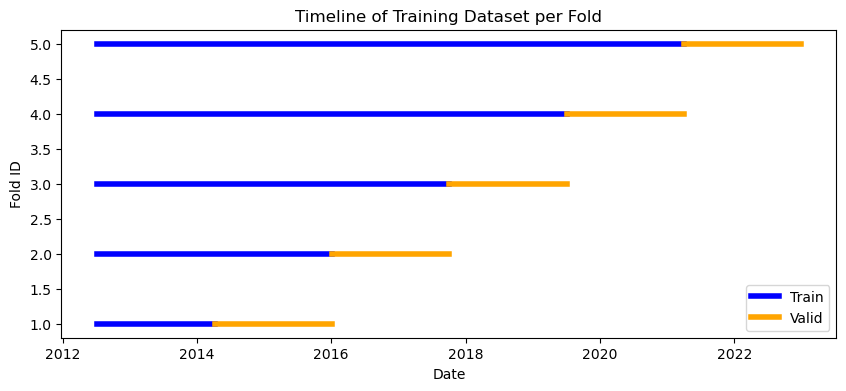

In [91]:
folds = []
cv_indices = cv.split(train_df)
for fold, (train_idx, val_idx) in enumerate(cv_indices, 1):
    folds.append(
        {
            "fold": fold,
            "train_start": train_df.iloc[train_idx]["Date"].min(),
            "train_end": train_df.iloc[train_idx]["Date"].max(),
            "val_start": train_df.iloc[val_idx]["Date"].min(),
            "val_end": train_df.iloc[val_idx]["Date"].max(),
        }
    )

folds_df = pd.DataFrame(folds)
fig, ax = plt.subplots(figsize=(10, 4))
for _, row in folds_df.iterrows():
    ax.plot(
        [row["train_start"], row["train_end"]],
        [row["fold"]] * 2,
        color="blue",
        linewidth=4,
        label="Train" if row["fold"] == 1 else "",
    )
    ax.plot(
        [row["val_start"], row["val_end"]],
        [row["fold"]] * 2,
        color="orange",
        linewidth=4,
        label="Valid" if row["fold"] == 1 else "",
    )
ax.set_title("Timeline of Training Dataset per Fold")
ax.set_xlabel("Date")
ax.set_ylabel("Fold ID")
ax.legend()
plt.show()


# 4 - Train Models

In [14]:
train_df, _ = build_forecasting_frame(sales)

cv = TimeSeriesSplit(n_splits=5)
cv_indices = cv.split(train_df)
daily_all = build_order_daily(orders, order_items, products)
target_col = "Revenue"
rows = []
ridge_alpha = 1.0
params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.08,
    "metric": "mae",
    "learning_rate": 0.07,
    "num_leaves": 35,
    "max_depth": 3,
    "min_child_samples": 8,
    "subsample": 0.8621387458595196,
    "subsample_freq": 1,
    "colsample_bytree": 0.4,
    "random_state": 42,
    "n_estimators": 3000,
    "reg_alpha": 4.4044962543997395e-06,
    "reg_lambda": 1.5454849393023623e-06,
    "verbosity": -1,
    "force_col_wise": True,
}

for fold, (tr_idx, va_idx) in enumerate(cv_indices, 1):
    fold_train_base = train_df.iloc[tr_idx].copy()
    fold_valid_base = train_df.iloc[va_idx].copy()

    train_start = fold_train_base["Date"].min()
    train_end = fold_train_base["Date"].max()
    valid_start = fold_valid_base["Date"].min()
    valid_end = fold_valid_base["Date"].max()

    # Baseline
    baseline_model = fit_seasonal_trend_baseline(
        train_df=fold_train_base,
        target_col=target_col,
    )
    baseline_pred = predict_seasonal_trend_baseline(
        model=baseline_model,
        df=fold_valid_base,
    )
    baseline_metrics = regression_metrics(
        y_true=fold_valid_base[target_col],
        y_pred=baseline_pred,
    )
    rows.append(
        {
            "fold": fold,
            "model": "Baseline",
            "train_start": train_start,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            **baseline_metrics,
        }
    )

    # Add some calendar features as baseline
    fold_train_model = add_calendar_features(fold_train_base.copy())
    fold_valid_model = add_calendar_features(fold_valid_base.copy())

    daily_fit = daily_all[daily_all["Date"] <= train_end].copy()
    fold_train_fe = add_order_templates(
        df=fold_train_model,
        daily_fit=daily_fit,
    )
    fold_valid_fe = add_order_templates(
        df=fold_valid_model,
        daily_fit=daily_fit,
    )

    # Ridge Regression
    ridge_model, ridge_feature_cols = train_ridge(
        train_df=fold_train_fe,
        valid_df=fold_valid_fe,
        target_col=target_col,
        alpha=ridge_alpha,
    )
    ridge_pred = predict_ridge(
        model=ridge_model,
        df=fold_valid_fe,
        feature_cols=ridge_feature_cols,
    )
    ridge_metrics = regression_metrics(
        y_true=fold_valid_fe[target_col],
        y_pred=ridge_pred,
    )
    rows.append(
        {
            "fold": fold,
            "model": "Ridge Regression",
            "train_start": train_start,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            **ridge_metrics,
        }
    )

    # LightGBM
    lgbm_model, feature_cols = train_lgbm(
        train_df=fold_train_fe,
        valid_df=fold_valid_fe,
        target_col=target_col,
        params=params,
    )
    lgbm_pred = predict_lgbm(
        model=lgbm_model,
        df=fold_valid_fe,
        feature_cols=feature_cols,
    )
    lgbm_metrics = regression_metrics(
        y_true=fold_valid_fe[target_col],
        y_pred=lgbm_pred,
    )
    rows.append(
        {
            "fold": fold,
            "model": "LightGBM",
            "train_start": train_start,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            **lgbm_metrics,
        }
    )

    print(
        f"Fold {fold} | "
        f"Baseline MAE={baseline_metrics['MAE']:.2f} | "
        f"Ridge MAE={ridge_metrics['MAE']:.2f} | "
        f"LGBM MAE={lgbm_metrics['MAE']:.2f}"
    )

result_df = pd.DataFrame(rows)
summary_df = (
    result_df.groupby("model")[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
    .reset_index()
)
summary_df


Fold 1 | Baseline MAE=4132622.11 | Ridge MAE=1241704.58 | LGBM MAE=1174030.05
Fold 2 | Baseline MAE=5764590.84 | Ridge MAE=1008536.37 | LGBM MAE=999521.59
Fold 3 | Baseline MAE=1651075.65 | Ridge MAE=1723347.28 | LGBM MAE=1370436.55
Fold 4 | Baseline MAE=926950.36 | Ridge MAE=1199501.47 | LGBM MAE=612809.20
Fold 5 | Baseline MAE=2447444.53 | Ridge MAE=794389.54 | LGBM MAE=527949.42


model           MAE                        RMSE                \
                             mean           std          mean           std   
0          Baseline  2.984537e+06  1.958765e+06  3.528931e+06  2.114745e+06   
1          LightGBM  9.369494e+05  3.606874e+05  1.283536e+06  5.134337e+05   
2  Ridge Regression  1.193496e+06  3.451806e+05  1.609631e+06  4.895616e+05   

         R2            
       mean       std  
0 -1.355864  1.617187  
1  0.698149  0.127913  
2  0.437860  0.345883

In [15]:
comparison_df = result_df.pivot(
    index = "fold", 
    columns= "model", 
    values = ["MAE", "RMSE", "R2"]
)
comparison_df

MAE                                         RMSE  \
model      Baseline      LightGBM Ridge Regression      Baseline   
fold                                                               
1      4.132622e+06  1.174030e+06     1.241705e+06  4.735084e+06   
2      5.764591e+06  9.995216e+05     1.008536e+06  6.561850e+06   
3      1.651076e+06  1.370437e+06     1.723347e+06  2.284243e+06   
4      9.269504e+05  6.128092e+05     1.199501e+06  1.256248e+06   
5      2.447445e+06  5.279494e+05     7.943895e+05  2.807232e+06   

                                            R2                             
model      LightGBM Ridge Regression  Baseline  LightGBM Ridge Regression  
fold                                                                       
1      1.564569e+06     1.665186e+06 -2.100696  0.661473         0.616532  
2      1.394523e+06     1.372793e+06 -3.347727  0.803636         0.809708  
3      1.930899e+06     2.376241e+06  0.295004  0.496243         0.237073  
4      8.081359e+05     1.582022e+06  0.332476  0.723761        -0.058622  
5      7.195544e+05     1.051911e+06 -1.958378  0.805632         0.584611

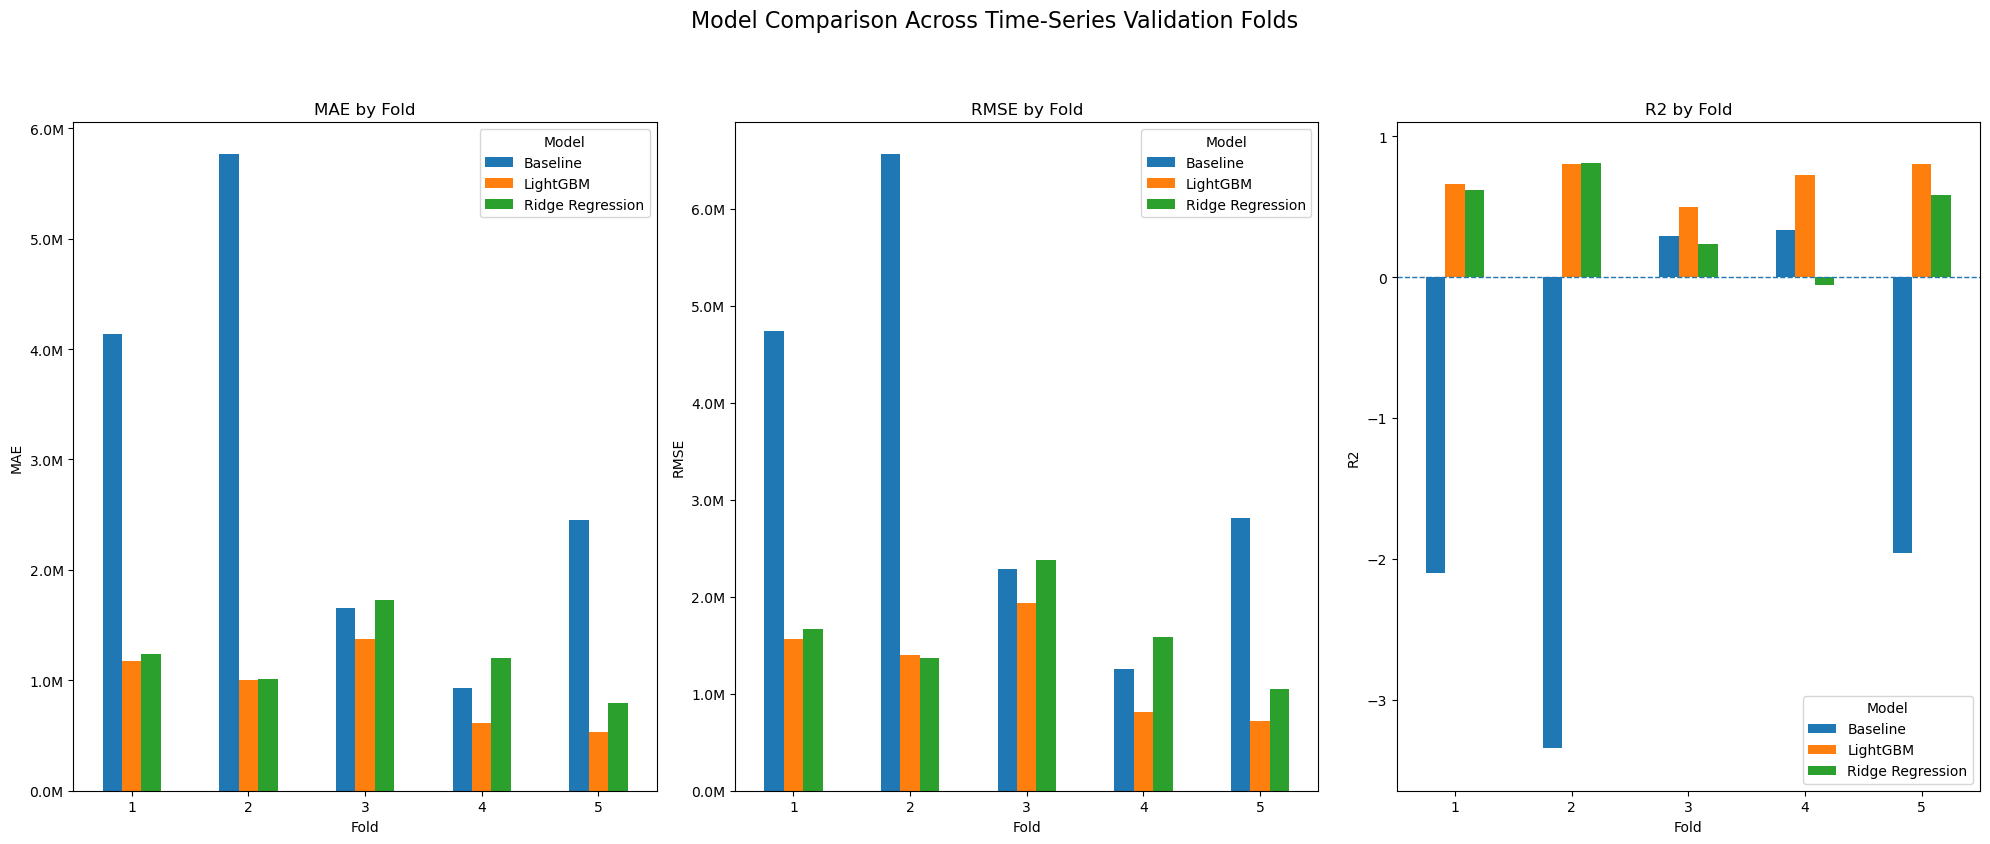

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

metrics = ["MAE", "RMSE", "R2"]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, metric in zip(axes, metrics):
    plot_df = result_df.pivot(index="fold", columns="model", values=metric)
    plot_df.plot(kind="bar", ax=ax)

    ax.set_title(f"{metric} by Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Model")

    if metric in ["MAE", "RMSE"]:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
        )

        for container in ax.containers:
            labels = [f"{v.get_height()/1e8:.2f}M" for v in container]
    else:
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_ylim(
            min(result_df["R2"].min() - 0.3, -0.5),
            max(result_df["R2"].max() + 0.1, 1.1)
        )

fig.suptitle("Model Comparison Across Time-Series Validation Folds", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [61]:
print(f"""
Qua 5 folds validation theo time series, notebook hiện so sánh 3 models: baseline, Ridge Regression và LightGBM. Trong đó Baseline là mốc tham chiếu đơn giản, 
Ridge Regression là benchmark tuyến tính có regularization, còn LightGBM đại diện cho mô hình phi tuyến. Mô hình có các chỉ số MAE, RMSE và R2 tốt nhất là LightGBM. 
""")


Qua 5 folds validation theo time series, notebook hiện so sánh 3 models: baseline, Ridge Regression và LightGBM. Trong đó Baseline là mốc tham chiếu đơn giản, 
Ridge Regression là benchmark tuyến tính có regularization, còn LightGBM đại diện cho mô hình phi tuyến. Mô hình có các chỉ số MAE, RMSE và R2 tốt nhất là LightGBM. 



# 5 - Data Pipeline

## 5.1 - Helpers

In [ ]:
MODEL_EXCLUDED_YEARS = [2020, 2012, 2013, 2014]
def build_master_feature_frame(sales):
    train_df, test_df = build_forecasting_frame(sales)
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df["is_train"] = 1
    test_df["is_train"] = 0
    test_df["Revenue"] = 0.0
    test_df["COGS"] = 0.0

    df_master = (
        pd.concat([train_df, test_df], ignore_index=True)
        .sort_values("Date")
        .reset_index(drop=True)
    )

    df_master = add_calendar_features(df_master)
    df_master = add_promo_features(df_master)
    return df_master

In [22]:
def log1p_clip(y):
    y = np.asarray(y)
    return np.log1p(np.clip(y, 0, None))


def expm1_clip(y):
    y = np.asarray(y)
    return np.clip(np.expm1(y), 0, None)

def flatten_feature_groups(feature_groups):
    cols = []
    seen = set()
    for group_cols in feature_groups.values():
        for col in group_cols:
            if col not in seen:
                cols.append(col)
                seen.add(col)
    return cols


## 5.2 - FeatureBuilder

In [23]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    
    def __init__(
        self,
        daily_all, drop_cols=None
    ):
        self.daily_all = daily_all.copy()
        self.drop_cols = ["Date", "Revenue", "COGS"] if drop_cols is None else drop_cols
    
    def fit(self, X, y = None):
        X = X.copy()
        self.daily_all_ = self.daily_all.copy()
        self.daily_fit_ = self.daily_all_[self.daily_all_["Date"] <= X["Date"].max()].copy()
        
        X_fe = add_order_templates(X, self.daily_fit_)
        self.feature_cols_ = [c for c in X_fe.columns if c not in self.drop_cols]
        return self
    def transform(self, X):
        X = X.copy()
        X_fe = add_order_templates(X, self.daily_fit_)

        # Nếu tranform có thiếu cột nào so với fit, thêm lại 
        for col in self.feature_cols_:
            if col not in X_fe.columns:
                X_fe[col] = np.nan 
                
        return X_fe[self.feature_cols_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_cols_, dtype=object)
    

## 5.3 - Pipeline

In [24]:
class Pipeline(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        daily_all,
        lgbm_params=None,
        early_stopping_rounds=150,
        drop_cols=None,
    ):
        self.daily_all = daily_all.copy()
        self.lgbm_params = lgbm_params
        self.early_stopping_rounds = early_stopping_rounds
        self.drop_cols = drop_cols if drop_cols is not None else ["Date", "Revenue", "COGS"]

    def fit(self, X, y, X_valid=None, y_valid=None):
        self.feature_builder_ = FeatureBuilder(
            daily_all=self.daily_all,
            drop_cols=self.drop_cols,
        )

        X_train_ready = self.feature_builder_.fit_transform(X)
        y_train = log1p_clip(y)

        self.X_train_ = X_train_ready.copy()
        self.y_train_ = y_train.copy()
        self.feature_names_out_ = X_train_ready.columns.tolist()
        self.feature_cols_ = self.feature_names_out_
        
        self.model_ = lgb.LGBMRegressor(
            **self.lgbm_params,
            importance_type="gain"
        )

        fit_kwargs = {}

        if X_valid is not None and y_valid is not None:
            X_valid_ready = self.feature_builder_.transform(X_valid)
            y_valid_log = log1p_clip(y_valid)

            self.X_valid_ = X_valid_ready.copy()
            self.y_valid_ = y_valid_log.copy()

            fit_kwargs["eval_set"] = [(X_valid_ready, y_valid_log)]
            fit_kwargs["eval_metric"] = "mae"
            fit_kwargs["callbacks"] = [
                lgb.early_stopping(
                    stopping_rounds=self.early_stopping_rounds,
                    verbose=False,
                ),
                lgb.log_evaluation(period=0),
            ]

        self.model_.fit(X_train_ready, y_train, **fit_kwargs)

        return self

    def predict(self, X):
        X_ready = self.feature_builder_.transform(X)

        best_iter = getattr(self.model_, "best_iteration_", None)

        if best_iter is not None and best_iter <= 0:
            best_iter = None

        pred_log = self.model_.predict(
            X_ready,
            num_iteration=best_iter
        )

        return expm1_clip(pred_log)

    def predict_log(self, X):
        X_ready = self.feature_builder_.transform(X)

        best_iter = getattr(self.model_, "best_iteration_", None)

        if best_iter is not None and best_iter <= 0:
            best_iter = None

        return self.model_.predict(
            X_ready,
            num_iteration=best_iter
        )

    def transform_features(self, X):
        return self.feature_builder_.transform(X)

    def get_feature_importance(self):
        return (
            pd.DataFrame(
                {
                    "feature": self.feature_names_out_,
                    "importance": self.model_.feature_importances_,
                }
            )
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

## 5.4 - Tuning Hyperparameters

In [ ]:
MODEL_EXCLUDED_YEARS = [2020, 2012, 2013, 2014]

df_master = build_master_feature_frame(sales)
train_df = (
    df_master[df_master["is_train"] == 1]
    .loc[lambda d: ~d["Date"].dt.year.isin(MODEL_EXCLUDED_YEARS)]
    .sort_values("Date")
    .reset_index(drop=True)
)

cv = TimeSeriesSplit(n_splits=5)
cv_indices = list(cv.split(train_df))
daily_all = build_order_daily(orders, order_items, products)
target_col = "Revenue"
drop_cols = ["Date", "Revenue", "COGS", "is_train", target_col]

def objective(trial):
    params = {
        "objective": "tweedie",
        "metric": "mae",
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.0, 1.8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        "n_estimators": 5000,
        "random_state": 42,
        "verbosity": -1,
        "force_col_wise": True,
    }

    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv_indices, 1):
        X_tr = train_df.iloc[tr_idx].copy()
        y_tr = X_tr[target_col].copy()

        X_va = train_df.iloc[va_idx].copy()
        y_va = X_va[target_col].copy()

        train_end = X_tr["Date"].max()
        daily_fit = daily_all[daily_all["Date"] <= train_end].copy()

        model = Pipeline(
            daily_all=daily_fit,
            lgbm_params=params,
            early_stopping_rounds=150,
            drop_cols=drop_cols,
        )

        model.fit(X_tr, y_tr, X_valid=X_va, y_valid=y_va)
        pred = model.predict(X_va)

        mae = mean_absolute_error(y_va, pred)
        scores.append(mae)

        trial.report(float(np.mean(scores)), step=fold)
        if fold >= 3 and trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.NopPruner(),
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-04-30 18:02:27,474] A new study created in memory with name: no-name-f539589a-b0ce-4408-b038-a021ed726c60


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-30 18:02:29,394] Trial 0 finished with value: 1029956.1183845585 and parameters: {'tweedie_variance_power': 1.29963209507789, 'learning_rate': 0.08927180304353628, 'num_leaves': 51, 'max_depth': 6, 'min_child_samples': 12, 'subsample': 0.2403950683025824, 'colsample_bytree': 0.3290418060840997, 'reg_alpha': 1.156732719914599, 'reg_lambda': 0.016136341713591334}. Best is trial 0 with value: 1029956.1183845585.
[I 2026-04-30 18:02:33,221] Trial 1 finished with value: 994463.5907573539 and parameters: {'tweedie_variance_power': 1.5664580622368365, 'learning_rate': 0.010485387725194618, 'num_leaves': 63, 'max_depth': 7, 'min_child_samples': 14, 'subsample': 0.26364247048639056, 'colsample_bytree': 0.3917022549267169, 'reg_alpha': 0.000134801802908908, 'reg_lambda': 0.004712973756110786}. Best is trial 1 with value: 994463.5907573539.
[I 2026-04-30 18:02:35,979] Trial 2 finished with value: 999101.2171028577 and parameters: {'tweedie_variance_power': 1.3455560149136927, 'learning

## 5.5 - Training Model

In [39]:
# Sau khi sử dụng best_params ở trên sử dụng, tại vì tunning hơi overfit nên MAE khá cao, chúng tôi dựa theo insight bộ dataset tune lại như bên dưới
best_params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.07,
    "metric": "mae",
    "learning_rate": 0.07,
    "num_leaves": 40,
    "max_depth": 3,
    "min_child_samples": 8,
    "subsample": 0.8621387458595196,
    "subsample_freq": 1,
    "colsample_bytree": 0.39,
    "random_state": 42,
    "n_estimators": 3000,
    "reg_alpha": 4.4044962543997395e-06,
    "reg_lambda": 1.5454849393023623e-06,
    "verbosity": -1,
    "force_col_wise": True,
}
MODEL_EXCLUDED_YEARS = [2020, 2012, 2013, 2014]
def cv_forecast_with_pipeline(
    sales,
    target_col,
    daily_all,
    n_splits=5,
    drop_cols=None,
):
    df_master = build_master_feature_frame(sales)
    train_df = df_master[df_master["is_train"] == 1]
    test_df = df_master[df_master["is_train"] == 0]
    train_df = (
        train_df[~train_df["Date"].dt.year.isin(MODEL_EXCLUDED_YEARS)]
        .sort_values("Date")
        .reset_index(drop=True)
    )
    test_df = test_df.sort_values("Date").reset_index(drop=True)

    drop_cols = ["Date", "Revenue", "COGS", "is_train", target_col]


    cv = TimeSeriesSplit(n_splits=n_splits)
    
    oof = np.full(len(train_df), np.nan)
    oof_fold = np.full(len(train_df), np.nan)
    test_pred = np.zeros(len(test_df))
    
    fold_importances = []
    fold_artifacts = []
    scores = []
    
    # best_params = study.best_params

    for fold, (tr_idx, va_idx) in enumerate(cv.split(train_df), 1):
        X_tr = train_df.iloc[tr_idx].copy()
        y_tr = train_df.iloc[tr_idx][target_col].copy()

        X_va = train_df.iloc[va_idx].copy()
        y_va = train_df.iloc[va_idx][target_col].copy()

        train_end = X_tr["Date"].max()
        daily_fit = daily_all[daily_all["Date"] <= train_end].copy()
        
        model = Pipeline(
            daily_all=daily_fit,
            lgbm_params=best_params,
            early_stopping_rounds=150,
            drop_cols=drop_cols,
        )
        
        model.fit(X_tr, y_tr, X_valid=X_va, y_valid=y_va)

        va_pred = model.predict(X_va)
        te_pred = model.predict(test_df.copy())

        oof[va_idx] = va_pred
        oof_fold[va_idx] = fold
        test_pred += te_pred / n_splits

        fi = model.get_feature_importance()
        fi["fold"] = fold 
        fold_importances.append(fi)


        score = regression_metrics(y_va, va_pred)
        score["fold"] = fold
        score["train_start"] = X_tr["Date"].min()
        score["train_end"] = X_tr["Date"].max()
        score["valid_start"] = X_va["Date"].min()
        score["valid_end"] = X_va["Date"].max()
        scores.append(score)
        
        best_iter = getattr(model.model_, "best_iteration_", None)

        fold_artifacts.append({
            "fold": fold,
            "model": model,
            "train_idx": tr_idx,
            "valid_idx": va_idx,
            "train_df": X_tr.copy(),
            "valid_df": X_va.copy(),
            "y_valid": y_va.copy(),
            "valid_pred": va_pred.copy(),
            "metrics": score,
        })
        
        print(f"{target_col} | Fold {fold}: best_iter={best_iter}, val_mae={score["MAE"]:.4f}")

    avg_fi = (
        pd.concat(fold_importances, ignore_index=True)
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    
    final_model = Pipeline(
        daily_all=daily_all,
        lgbm_params=best_params,
        early_stopping_rounds=150,
        drop_cols=drop_cols,
    )
    final_model.fit(train_df.copy(), train_df[target_col].copy())

    train_curve = train_df[["Date", target_col]].copy().rename(columns={target_col: "actual"})
    train_curve["pred"] = oof
    train_curve["fold"] = oof_fold
    train_curve["residual"] = train_curve["actual"] - train_curve["pred"]
    train_curve["abs_error"] = train_curve["residual"].abs()
    train_curve["ape"] = train_curve["abs_error"] / train_curve["actual"].replace(0, np.nan)

    test_curve = test_df[["Date"]].copy()
    test_curve["pred"] = test_pred

    metrics_df = pd.DataFrame(scores)
    return {
        "train_df": train_df,
        "test_df": test_df,
        "metrics": metrics_df,
        "train_curve": train_curve,
        "test_curve": test_curve,
        "test_pred": test_pred,
        "feature_importance": avg_fi,
        "fold_importance": pd.concat(fold_importances, ignore_index = True),
        "fold_artifacts": fold_artifacts,
        "final_model": final_model,
    }


In [40]:
daily_all = build_order_daily(orders, order_items, products)
revenue_result = cv_forecast_with_pipeline(
    sales,
    "Revenue",
    daily_all)
cogs_result = cv_forecast_with_pipeline(
    sales,
    "COGS",
    daily_all)


Revenue | Fold 1: best_iter=84, val_mae=1187420.2745
Revenue | Fold 2: best_iter=89, val_mae=1046556.7102
Revenue | Fold 3: best_iter=534, val_mae=1588717.0571
Revenue | Fold 4: best_iter=337, val_mae=532110.0710
Revenue | Fold 5: best_iter=82, val_mae=582126.8695
COGS | Fold 1: best_iter=68, val_mae=911194.6830
COGS | Fold 2: best_iter=70, val_mae=931607.0114
COGS | Fold 3: best_iter=499, val_mae=1403420.6499
COGS | Fold 4: best_iter=148, val_mae=509000.2307
COGS | Fold 5: best_iter=39, val_mae=510982.9276


In [41]:
submission = revenue_result["test_df"][["Date"]].copy()
submission["Revenue"] = revenue_result["test_pred"]
submission["COGS"] = cogs_result["test_pred"]
submission.to_csv(r"dataset/submission.csv", index = False)


# 6 - Model Evaluation

## 6.1 - Cross-validation Metrics

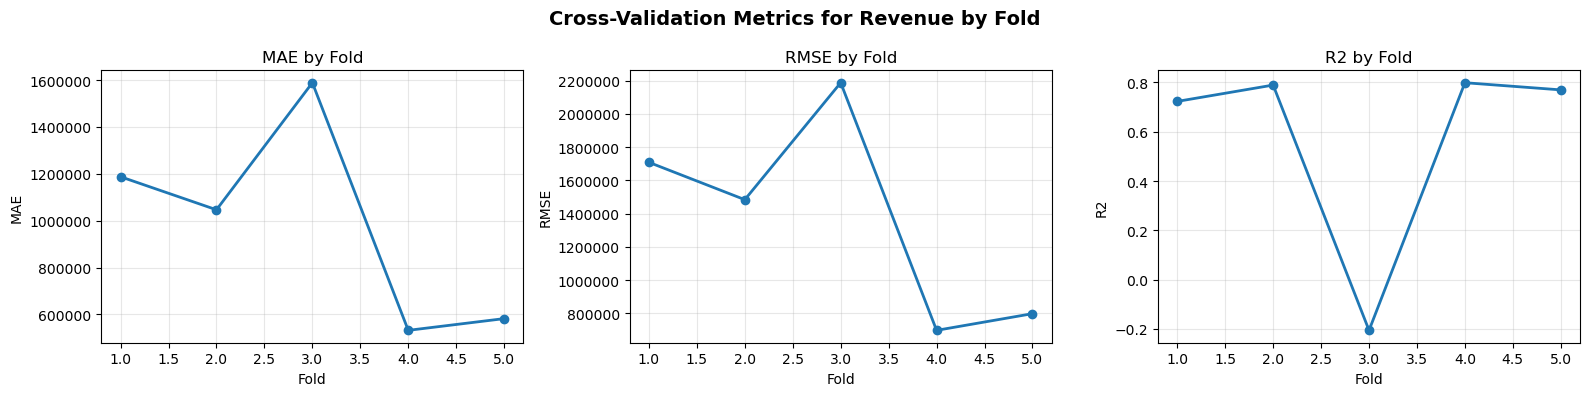

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = revenue_result["metrics"]
metric = ["MAE", "RMSE", "R2"]

for ax, metric in zip(axes, metric):
    ax.plot(
        metrics["fold"],
        metrics[metric],
        marker="o",
        linewidth=2
    )

    ax.set_title(f"{metric} by Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)

    if metric in ["MAE", "RMSE"]:
        ax.ticklabel_format(style="plain", axis="y")

fig.suptitle("Cross-Validation Metrics for Revenue by Fold", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Cross-validation cho thấy mô hình có khả năng dự báo doanh thu tương đối tốt, nhưng hiệu suất chưa hoàn toàn ổn định theo thời gian. Fold 3 có lỗi cao nhất, trong khi fold 4 và fold 5 cải thiện rõ rệt. Vì đây là bài toán time-series, sự khác biệt giữa các fold là tín hiệu quan trọng: model không chỉ cần score trung bình tốt, mà còn cần được kiểm tra xem lỗi tập trung ở giai đoạn nào. Do đó, nhóm không chỉ dùng average CV score để đánh giá mô hình, mà tiếp tục phân tích residual, feature importance và SHAP để hiểu mô hình đang học từ những yếu tố kinh doanh nào và sai ở những giai đoạn nào.

## 6.2 - Out-of-fold Prediction Analysis

In [65]:
eval_curve = revenue_result["train_curve"].dropna(subset= ["pred"]).copy()
eval_curve.head()

,Date,actual,pred,fold,residual,abs_error,ape
426,2016-03-02,1479744.00,2.028213e+06,1.0,-5.484689e+05,5.484689e+05,0.370651
427,2016-03-03,2251060.05,3.510740e+06,1.0,-1.259680e+06,1.259680e+06,0.559594
428,2016-03-04,2778579.79,3.322789e+06,1.0,-5.442090e+05,5.442090e+05,0.195859
429,2016-03-05,3472294.22,4.084653e+06,1.0,-6.123591e+05,6.123591e+05,0.176356
430,2016-03-06,3501407.51,4.017618e+06,1.0,-5.162108e+05,5.162108e+05,0.147430


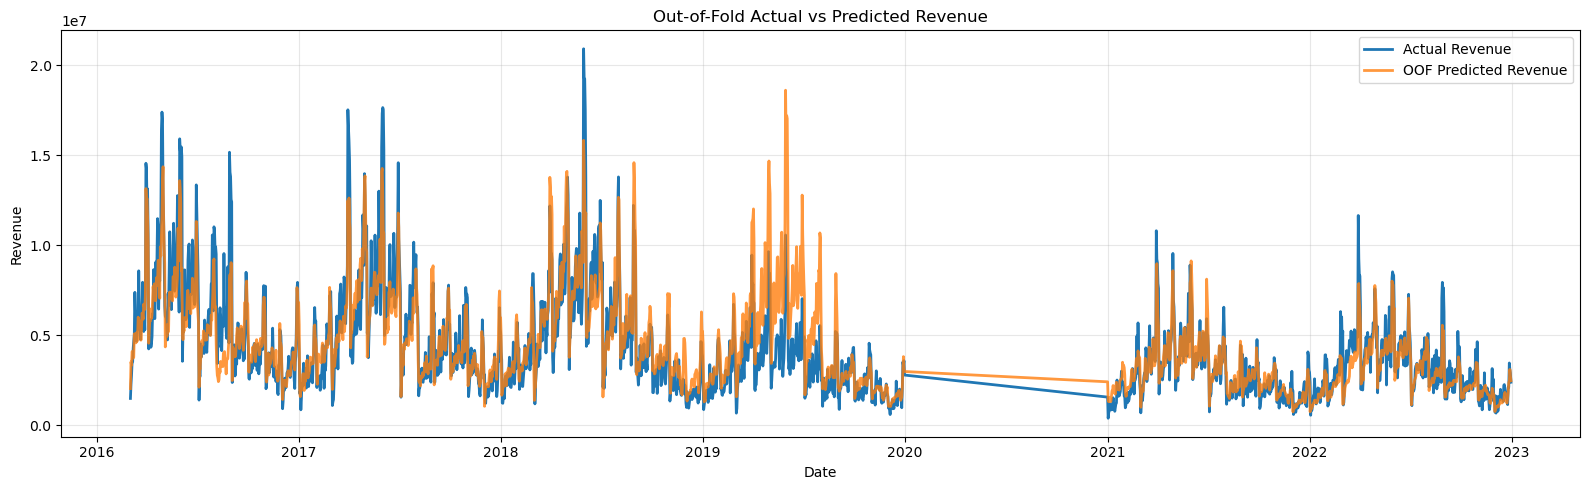

In [66]:
plt.figure(figsize=(16, 5))

plt.plot(
    eval_curve["Date"],
    eval_curve["actual"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    eval_curve["Date"],
    eval_curve["pred"],
    label="OOF Predicted Revenue",
    linewidth=2,
    alpha=0.8
)

plt.title("Out-of-Fold Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Đường dự báo OOF nhìn chung bám theo đường doanh thu thực tế, cho thấy mô hình học được xu hướng và seasonality chính. Tuy nhiên, ở các ngày doanh thu spike mạnh, prediction thường bị làm mượt và không bắt hết biên độ tăng/giảm.

## 6.3 - Residual Diagnostics

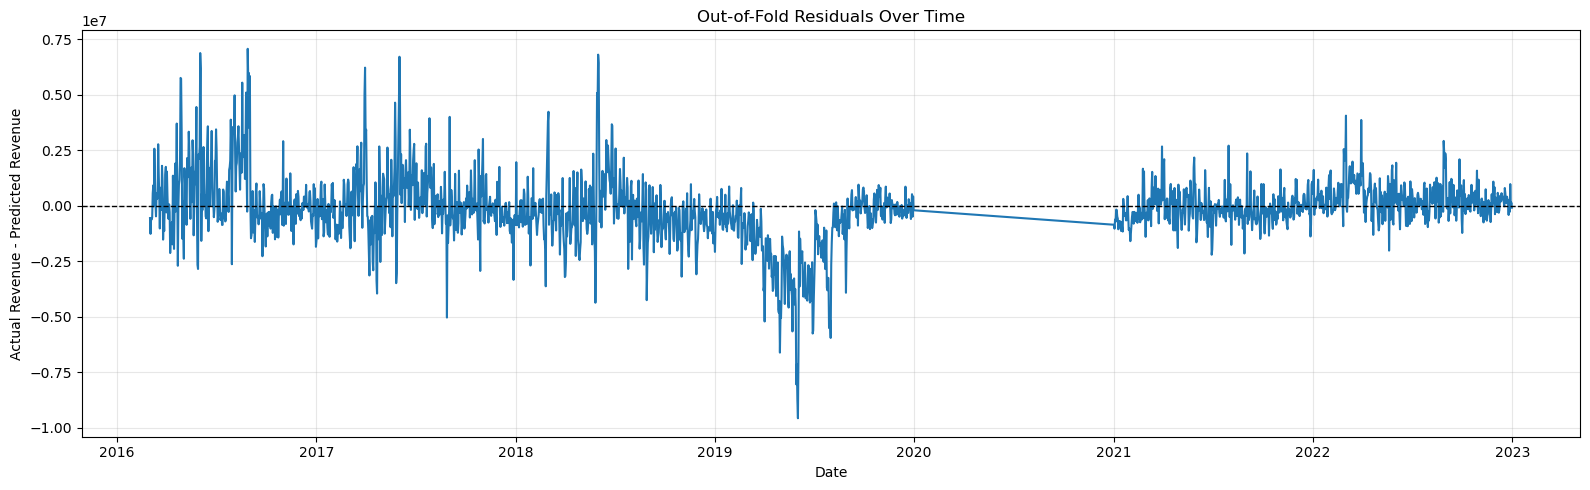

In [67]:
plt.figure(figsize=(16, 5))

plt.plot(
    eval_curve["Date"],
    eval_curve["residual"],
    linewidth=1.5
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Out-of-Fold Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Actual Revenue - Predicted Revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Phân tích residual cho thấy mô hình dự báo tương đối tốt các pattern doanh thu thông thường, nhưng còn yếu ở các giai đoạn biến động mạnh. Trong các năm đầu, residual dương lớn cho thấy model thường dự báo thấp các ngày doanh thu spike. Ngược lại, quanh năm 2019, residual âm kéo dài cho thấy model có xu hướng dự báo cao hơn thực tế một cách có hệ thống. Từ 2021 trở đi, residual tập trung quanh 0 hơn và biên độ sai số nhỏ hơn, cho thấy mô hình ổn định hơn ở các fold sau.

## 6.4 - Error Driver Analysis

In [68]:
top_error_days = (
    eval_curve
    .sort_values("abs_error", ascending=False)
    .head(50)
    .rename(columns={"Date": "date"})
    .copy()
)
eval_all = (
    eval_curve
    .dropna(subset=["pred"])
    .rename(columns={"Date": "date"})
    .copy()
)
order_daily = (
    orders
    .groupby("order_date", as_index=False)
    .agg(
        order_count=("order_id", "nunique")
    )
    .rename(columns={"order_date": "date"})
)

item_promo_daily = (
    orders[["order_date", "order_id"]]
    .merge(order_items[["order_id", "product_id", "quantity", "promo_id"]], on="order_id", how="left")
    .merge(promotions[["promo_id", "promo_name"]], on="promo_id", how="left")
    .groupby("order_date", as_index=False)
    .agg(
        item_count=("product_id", "count"),
        total_quantity=("quantity", "sum"),
        promo_item_count=("promo_id", lambda x: x.notna().sum()),
        promo_names=("promo_name", lambda x: sorted(x.dropna().unique().tolist()))
    )
    .rename(columns={"order_date": "date"})
)

top_error_inspection = (
    top_error_days
    .merge(web_traffic[["date", "sessions", "unique_visitors"]], on="date", how="left")
    .merge(order_daily, on="date", how="left")
    .merge(item_promo_daily, on="date", how="left")
)
top_error_inspection["has_promo"] = top_error_inspection["promo_item_count"].fillna(0) > 0
top_error_inspection["promo_share"] = (
    top_error_inspection["promo_item_count"] / top_error_inspection["item_count"]
).replace([np.inf, -np.inf], np.nan)


eval_all_inspection = (
    eval_all
    .merge(web_traffic[["date", "sessions", "unique_visitors"]], on="date", how="left")
    .merge(order_daily, on="date", how="left")
    .merge(item_promo_daily, on="date", how="left")
)
eval_all_inspection["has_promo"] = eval_all_inspection["promo_item_count"].fillna(0) > 0
eval_all_inspection["promo_share"] = (
    eval_all_inspection["promo_item_count"] / eval_all_inspection["item_count"]
).replace([np.inf, -np.inf], np.nan)

top_error_dates = set(top_error_inspection["date"])
eval_all_inspection["is_top_error"] = eval_all_inspection["date"].isin(top_error_dates)

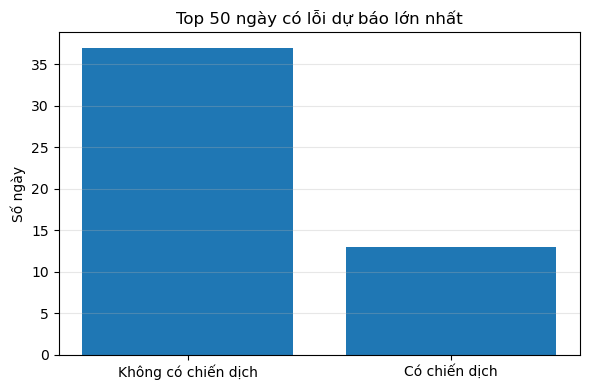

,group,n_days
0,Không có chiến dịch,37
1,Có chiến dịch,13


In [70]:
promo_flag_count = (
    top_error_inspection["has_promo"]
    .map({True: "Có chiến dịch", False: "Không có chiến dịch"})
    .value_counts()
    .reset_index()
)

promo_flag_count.columns = ["group", "n_days"]

plt.figure(figsize=(6, 4))
plt.bar(promo_flag_count["group"], promo_flag_count["n_days"])

plt.title("Top 50 ngày có lỗi dự báo lớn nhất")
plt.ylabel("Số ngày")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
promo_flag_count


Khi kiểm tra 50 ngày có lỗi dự báo lớn nhất, chỉ có 13 ngày liên kết trực tiếp với promotion thông qua promo_id. Điều này cho thấy promotion chỉ giải thích một phần nhỏ các lỗi lớn. Các lỗi còn lại có khả năng đến từ demand shock không được ghi nhận như promotion, biến động traffic, order volume, hoặc thay đổi pattern doanh thu theo thời gian.

In [71]:
compare_summary = (
    eval_all_inspection
    .groupby("is_top_error", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_sessions=("sessions", "mean"),
        median_sessions=("sessions", "median"),
        mean_unique_visitors=("unique_visitors", "mean"),
        median_unique_visitors=("unique_visitors", "median"),
        mean_order_count=("order_count", "mean"),
        median_order_count=("order_count", "median"),
        mean_item_count=("item_count", "mean"),
        mean_total_quantity=("total_quantity", "mean"),
        promo_day_rate=("has_promo", "mean"),
    )
)

compare_summary["group"] = np.where(
    compare_summary["is_top_error"],
    "Top 50 error days",
    "Other OOF days"
)

In [72]:
summary = compare_summary.copy()

base = summary[summary["group"] == "Other OOF days"].iloc[0]
top = summary[summary["group"] == "Top 50 error days"].iloc[0]

lift_table = pd.DataFrame({
    "metric": [
        "mean_abs_error",
        "mean_sessions",
        "mean_unique_visitors",
        "mean_order_count",
        "mean_item_count",
        "mean_total_quantity",
        "promo_day_rate"
    ],
    "other_oof_days": [
        base["mean_abs_error"],
        base["mean_sessions"],
        base["mean_unique_visitors"],
        base["mean_order_count"],
        base["mean_item_count"],
        base["mean_total_quantity"],
        base["promo_day_rate"],
    ],
    "top_error_days": [
        top["mean_abs_error"],
        top["mean_sessions"],
        top["mean_unique_visitors"],
        top["mean_order_count"],
        top["mean_item_count"],
        top["mean_total_quantity"],
        top["promo_day_rate"],
    ],
})

lift_table["ratio_top_vs_other"] = (
    lift_table["top_error_days"] / lift_table["other_oof_days"]
)

lift_table["pct_change"] = (
    lift_table["ratio_top_vs_other"] - 1
) * 100

lift_table_display = lift_table.copy()

lift_table_display["other_oof_days"] = lift_table_display["other_oof_days"].round(2)
lift_table_display["top_error_days"] = lift_table_display["top_error_days"].round(2)
lift_table_display["ratio_top_vs_other"] = lift_table_display["ratio_top_vs_other"].round(2)
lift_table_display["pct_change"] = lift_table_display["pct_change"].round(1)

lift_table_display

,metric,other_oof_days,top_error_days,ratio_top_vs_other,pct_change
0,mean_abs_error,876933.34,5582225.17,6.37,536.6
1,mean_sessions,27027.32,34480.38,1.28,27.6
2,mean_unique_visitors,20532.30,26209.20,1.28,27.6
3,mean_order_count,150.12,371.22,2.47,147.3
4,mean_item_count,163.01,405.36,2.49,148.7
5,mean_total_quantity,733.00,1815.88,2.48,147.7
6,promo_day_rate,0.49,0.26,0.53,-46.5


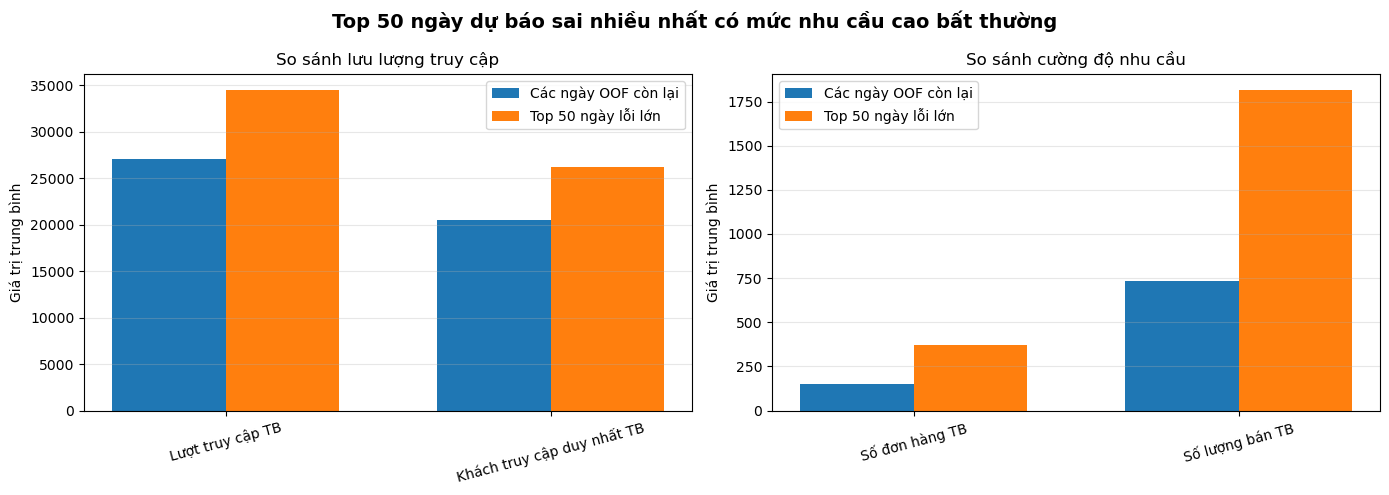

In [73]:

# Chọn các chỉ số cần so sánh
plot_cols = [
    "mean_sessions",
    "mean_unique_visitors",
    "mean_order_count",
    "mean_total_quantity",
    "promo_day_rate"
]

# Đưa bảng compare_summary về dạng dễ vẽ
plot_df = (
    compare_summary
    .set_index("group")
    .loc[["Other OOF days", "Top 50 error days"], plot_cols]
    .T
    .reset_index()
)

plot_df = plot_df.rename(columns={
    "index": "metric",
    "Other OOF days": "Các ngày OOF còn lại",
    "Top 50 error days": "Top 50 ngày lỗi lớn"
})

# Tách nhóm chỉ số traffic và nhóm chỉ số nhu cầu thực tế
traffic_metrics = ["mean_sessions", "mean_unique_visitors"]
demand_metrics = ["mean_order_count", "mean_total_quantity"]

traffic_df = plot_df[plot_df["metric"].isin(traffic_metrics)].copy()
demand_df = plot_df[plot_df["metric"].isin(demand_metrics)].copy()

metric_labels = {
    "mean_sessions": "Lượt truy cập TB",
    "mean_unique_visitors": "Khách truy cập duy nhất TB",
    "mean_order_count": "Số đơn hàng TB",
    "mean_total_quantity": "Số lượng bán TB"
}

traffic_df["metric_label"] = traffic_df["metric"].map(metric_labels)
demand_df["metric_label"] = demand_df["metric"].map(metric_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35

# Biểu đồ 1: So sánh traffic
x = np.arange(len(traffic_df))

axes[0].bar(
    x - width / 2,
    traffic_df["Các ngày OOF còn lại"],
    width,
    label="Các ngày OOF còn lại"
)

axes[0].bar(
    x + width / 2,
    traffic_df["Top 50 ngày lỗi lớn"],
    width,
    label="Top 50 ngày lỗi lớn"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(traffic_df["metric_label"], rotation=15)
axes[0].set_title("So sánh lưu lượng truy cập")
axes[0].set_ylabel("Giá trị trung bình")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Biểu đồ 2: So sánh nhu cầu / đơn hàng
x = np.arange(len(demand_df))

axes[1].bar(
    x - width / 2,
    demand_df["Các ngày OOF còn lại"],
    width,
    label="Các ngày OOF còn lại"
)

axes[1].bar(
    x + width / 2,
    demand_df["Top 50 ngày lỗi lớn"],
    width,
    label="Top 50 ngày lỗi lớn"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(demand_df["metric_label"], rotation=15)
axes[1].set_title("So sánh cường độ nhu cầu")
axes[1].set_ylabel("Giá trị trung bình")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Top 50 ngày dự báo sai nhiều nhất có mức nhu cầu cao bất thường",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Top 50 ngày dự báo sai nhiều nhất có traffic cao hơn các ngày OOF còn lại, nhưng mức tăng mạnh nhất nằm ở số đơn hàng và tổng số lượng bán ra. Điều này cho thấy lỗi lớn của mô hình không chỉ đến từ lưu lượng truy cập cao, mà chủ yếu đến từ các ngày nhu cầu thực tế tăng bất thường. Đáng chú ý, tỷ lệ ngày có khuyến mãi trong nhóm top-error thấp hơn nhóm ngày còn lại, nên không thể kết luận lỗi lớn chủ yếu do promotion. Điểm yếu chính của mô hình là dự báo các ngày demand spike hoặc conversion spike.

Sau khi phân tích residual, nhóm nhận thấy các lỗi lớn tập trung ở những ngày có demand/order spike hơn là chỉ ở ngày promotion. Vì vậy, bước tiếp theo là kiểm tra model đang dựa vào những nhóm feature nào để dự báo doanh thu. Feature importance và SHAP được sử dụng để đánh giá liệu mô hình có học được các driver kinh doanh hợp lý như seasonality, recent demand momentum, traffic signal, order activity và promotion effect hay không.

## 6.5 - Feature Importance

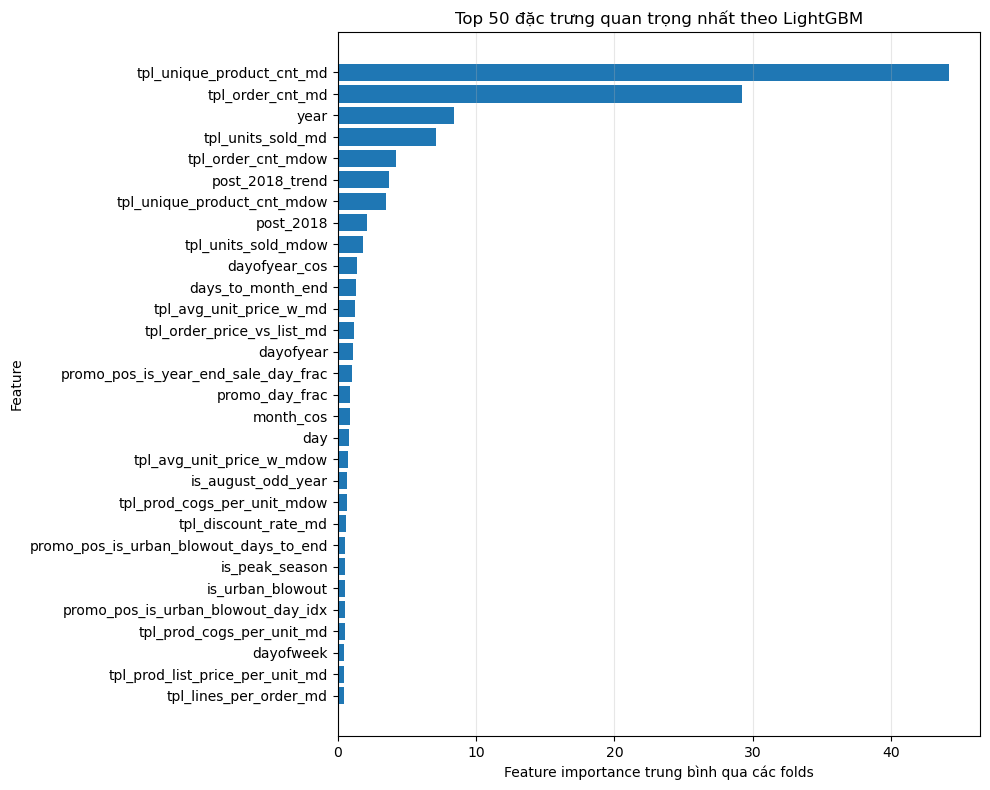

In [75]:
fi_plot = (
    revenue_result["feature_importance"]
    .sort_values("importance", ascending=False)
    .head(30)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    fi_plot["feature"],
    fi_plot["importance"]
)

plt.title("Top 50 đặc trưng quan trọng nhất theo LightGBM")
plt.xlabel("Feature importance trung bình qua các folds")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

LightGBM thấy các biến mô tả quy mô hoạt động bán hàng lịch sử theo ngày/tháng/thứ trong tuần là nhóm feature quan trọng nhất. Đặc biệt, `tpl_unique_product_cnt_md `và `tpl_order_cnt_md` vượt xa các biến còn lại, cho thấy doanh thu ngày được giải thích mạnh bởi số lượng sản phẩm unique thường được bán và số lượng order template trong các ngày tương tự. Doanh thu hằng ngày không chỉ phụ thuộc vào ngày/tháng hay campaign, mà bị chi phối mạnh bởi “dấu vết nhu cầu lịch sử” từ dữ liệu giao dịch. Những ngày có template lịch sử cho thấy số lượng đơn hàng, số sản phẩm bán ra và độ đa dạng sản phẩm cao thường tương ứng với mức doanh thu cao hơn.

## 6.6 - SHAP

Tuy nhiên, feature importance chỉ cho biết mức độ quan trọng tương đối của feature, chưa cho biết giá trị cao/thấp của feature kéo dự báo Revenue lên hay xuống. Vì vậy, nhóm tiếp tục sử dụng SHAP để phân tích chiều tác động của các driver chính.

In [76]:
import shap

final_model = revenue_result["final_model"]

X_shap = final_model.X_train_.copy()

sample_size = min(2000, len(X_shap))
X_shap_sample = X_shap.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(final_model.model_)
shap_values = explainer.shap_values(X_shap_sample)

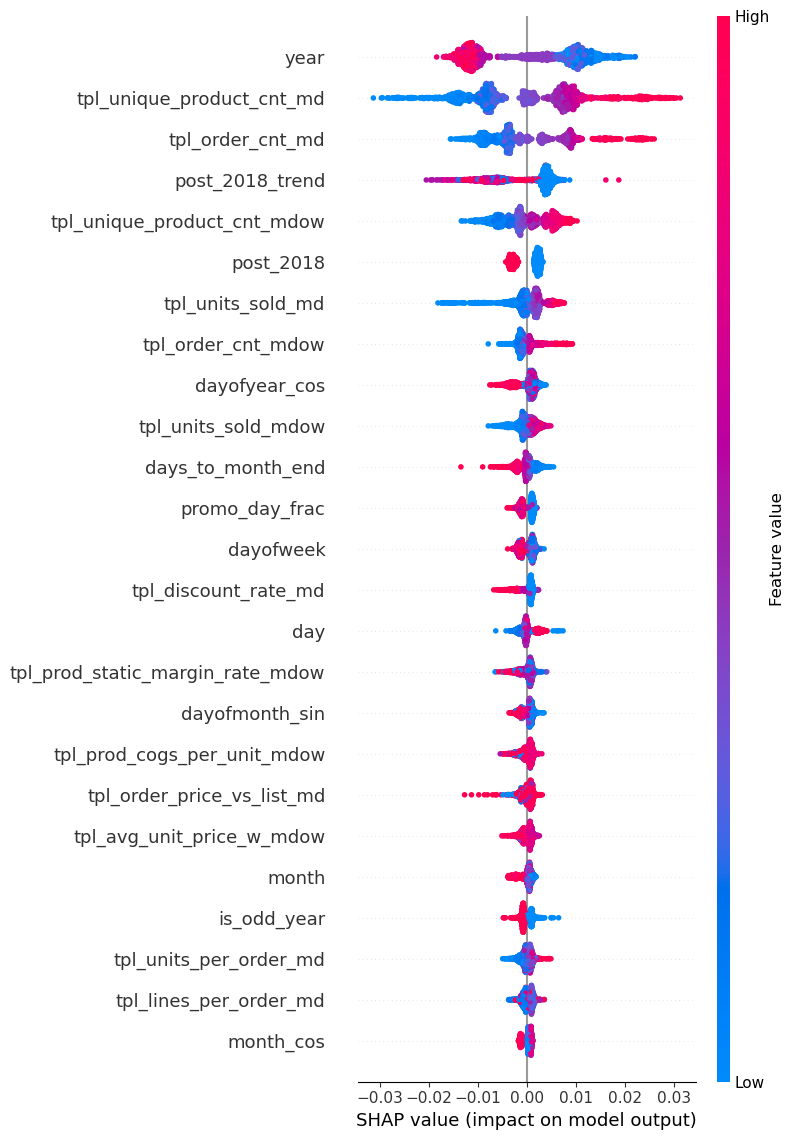

In [77]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    max_display=25,
    show=True
)

SHAP cho thấy biến `year`, `post_2018` và `post_2018_trend` có ảnh hưởng lớn vì mô hình nhận diện được sự thay đổi cấu trúc doanh thu theo thời gian. Sau cú rơi/đứt gãy quanh giai đoạn 2018, Revenue có dấu hiệu phục hồi, nhưng mức nền mới vẫn thấp hơn giai đoạn tăng trưởng mạnh 2015–2018. Vì vậy, các năm sau 2020 không nhất thiết biểu thị thị trường tiếp tục xấu đi, mà phản ánh việc doanh nghiệp bước sang một regime doanh thu thấp hơn so với giai đoạn trước.

Số lượng sản phẩm unique được bán trong các ngày tương tự là một trong những driver mạnh nhất của Revenue. Khi độ đa dạng sản phẩm bán ra cao, SHAP value thường dương, cho thấy model nâng dự báo doanh thu. Điều này gợi ý rằng revenue growth không chỉ đến từ bán nhiều unit của một vài sản phẩm, mà còn từ việc mở rộng breadth của giỏ hàng và danh mục sản phẩm được tiêu thụ.

Quy mô đơn hàng lịch sử là driver trực tiếp của Revenue. Các ngày có số lượng order template cao thường làm tăng dự báo doanh thu, cho thấy demand volume vẫn là yếu tố nền tảng nhất trong forecasting.

Nhóm feature về promotion phase có xuất hiện trong top features, đặc biệt làm `promo_day_frac` và các biến liên quan đến Year-End Sale/Urban Blowout. Điều này cho thấy mô hình không chỉ học việc “có khuyến mãi hay không”, mà còn học vị trí của ngày trong vòng đời campaign. Tuy nhiên, mức độ quan trọng của nhóm promotion thấp hơn nhóm demand-template features, hàm ý rằng promotion tác động lên doanh thu nhưng cần được đặt trong bối cảnh nhu cầu nền và seasonality.